# SC475 - Time Series Analysis  

## Topic: Time Series Analysis of Daily Bitcoin Closing Prices  

- **Madhav Kanjilimadom** - 202203018
- **Manan Patel** - 202201310
- **Jash Shah** – 202201016

- **Guide - Prof. Mukesh Tiwari**


#1. Importing Necessary Libraries and Loading Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from scipy import stats
import statsmodels.api as sm
import warnings
from itertools import product
from datetime import datetime
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.stattools import adfuller

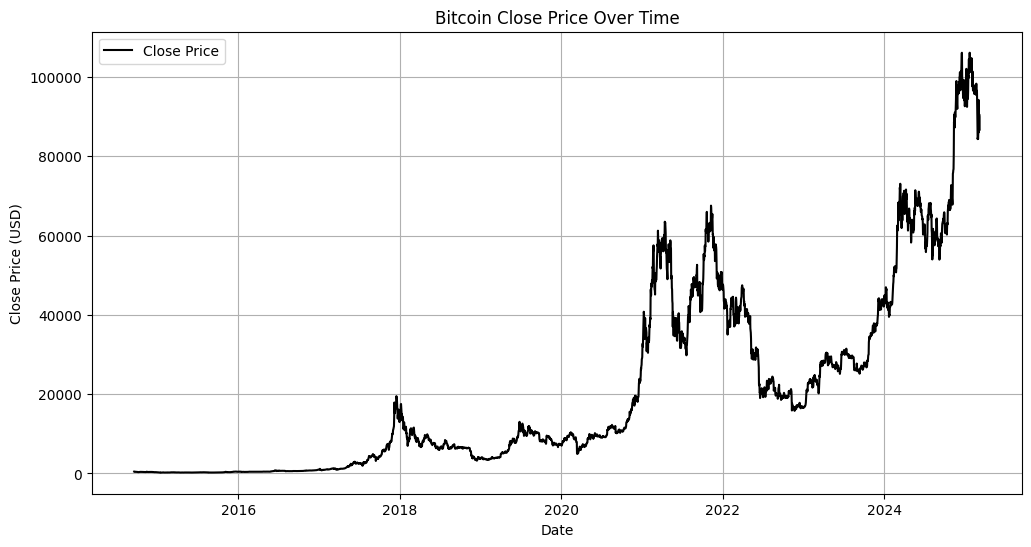

In [ ]:
# Define the Bitcoin ticker symbol
btc = yf.Ticker("BTC-USD")

# Fetch historical data from 2014 to 2025
btc_data = btc.history(start="2014-01-01", end="2025-03-08", interval="1d")

# Remove timezone information
btc_data.index = btc_data.index.tz_localize(None)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(btc_data.index, btc_data['Close'], label='Close Price', color='black')

# Formatting
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.title('Bitcoin Close Price Over Time')
plt.legend()
plt.grid(True)
plt.show()

#2. Exploratory Data Analysis(EDA)

In [ ]:
df = btc_data
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3825 entries, 2014-09-17 to 2025-03-07
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          3825 non-null   float64
 1   High          3825 non-null   float64
 2   Low           3825 non-null   float64
 3   Close         3825 non-null   float64
 4   Volume        3825 non-null   int64  
 5   Dividends     3825 non-null   float64
 6   Stock Splits  3825 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 239.1 KB


In [ ]:
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0
2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,0.0,0.0
2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,0.0,0.0
2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,0.0,0.0
2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,0.0,0.0


In [ ]:
df.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-03-03,94248.421875,94429.750000,85081.304688,86065.671875,70072228536,0.0,0.0
2025-03-04,86064.070312,88911.273438,81529.242188,87222.195312,68095241474,0.0,0.0
2025-03-05,87222.953125,90998.242188,86379.773438,90623.562500,50498988027,0.0,0.0
2025-03-06,90622.359375,92804.937500,87852.140625,89961.726562,47749810486,0.0,0.0
2025-03-07,89963.281250,91191.046875,84717.679688,86742.671875,65945677657,0.0,0.0


In [ ]:
df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0


In [ ]:
df.shape

(3825, 7)

In [ ]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,3825.000000,3825.000000,3825.000000,3825.000000,3.825000e+03,3825.0,3825.0
mean,20896.814878,21361.920959,20406.313626,20918.184380,1.912928e+10,0.0,0.0
std,24120.780905,24635.700511,23573.315113,24140.436693,2.082376e+10,0.0,0.0
min,176.897003,211.731003,171.509995,178.102997,5.914570e+06,0.0,0.0
25%,1321.869995,1347.910034,1315.209961,1347.890015,5.796350e+08,0.0,0.0
50%,9533.784180,9711.889648,9347.593750,9538.024414,1.522294e+10,0.0,0.0
75%,33811.242188,34719.253906,32318.880859,33798.011719,3.032714e+10,0.0,0.0
max,106147.296875,109114.882812,105291.734375,106146.265625,3.509679e+11,0.0,0.0


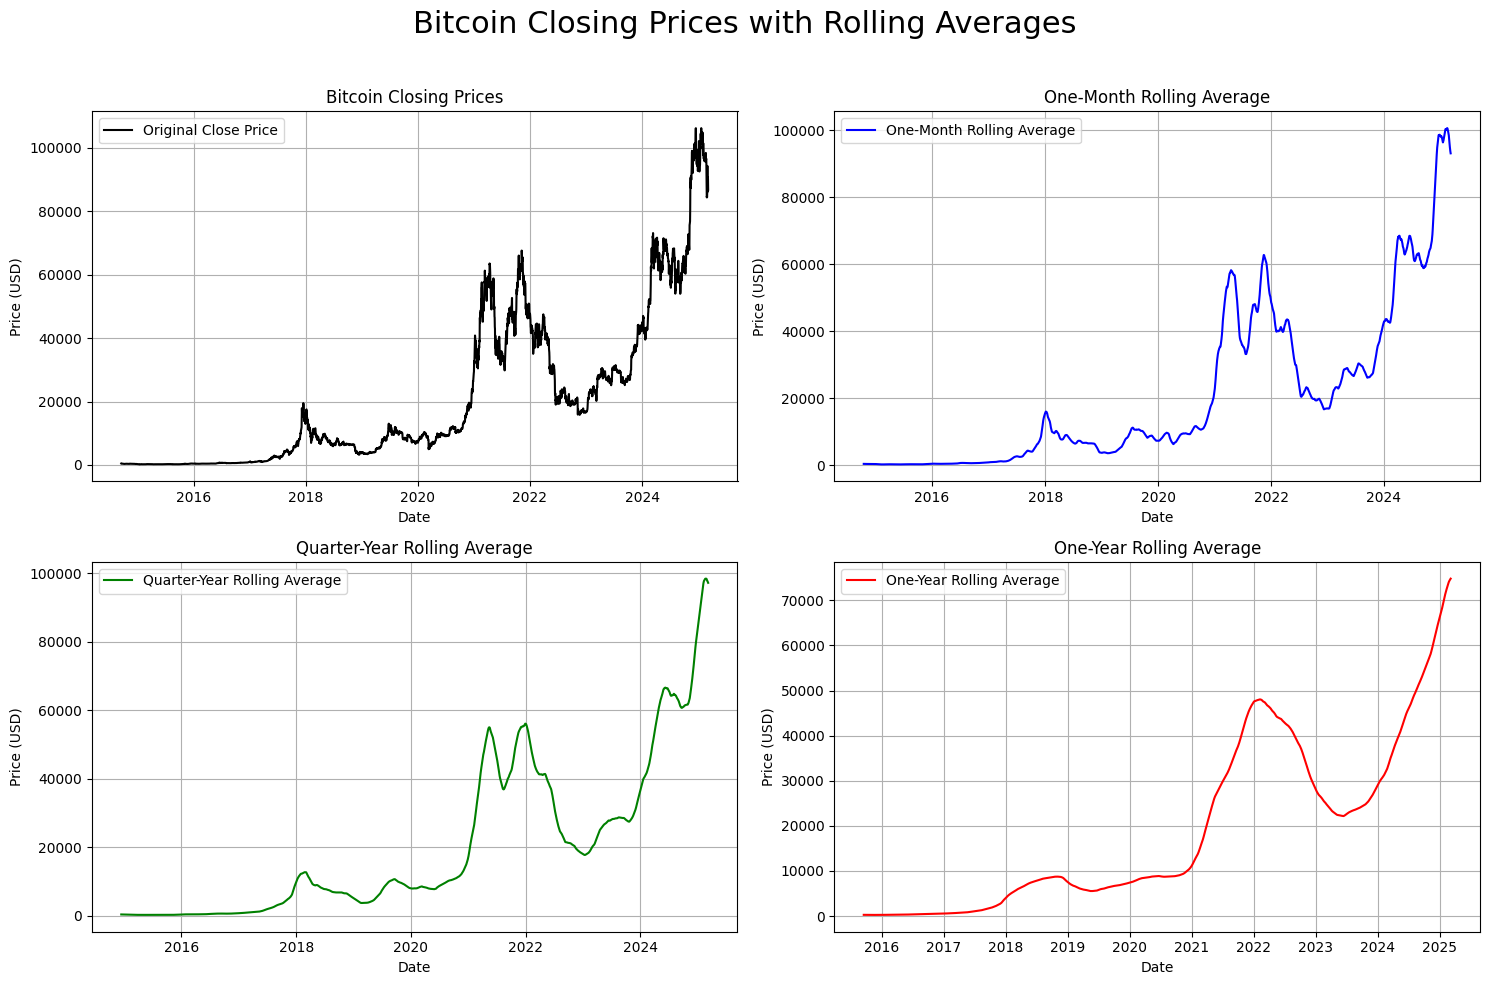

In [ ]:
# Calculate rolling averages (if not already done)
df['rolling_month'] = df['Close'].rolling(window=30).mean()
df['rolling_quarter'] = df['Close'].rolling(window=90).mean()
df['rolling_year'] = df['Close'].rolling(window=365).mean()

# Create a figure with a 2x2 subplot layout
fig = plt.figure(figsize=[15, 10])
plt.suptitle('Bitcoin Closing Prices with Rolling Averages', fontsize=22)

# Subplot 1: Original Close Price
plt.subplot(221)
plt.plot(df.index, df['Close'], label='Original Close Price', color='black')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.title('Bitcoin Closing Prices')

# Subplot 2: One-Month Rolling Average
plt.subplot(222)
plt.plot(df.index, df['rolling_month'], label='One-Month Rolling Average', color='blue')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.title('One-Month Rolling Average')

# Subplot 3: Quarter-Year Rolling Average
plt.subplot(223)
plt.plot(df.index, df['rolling_quarter'], label='Quarter-Year Rolling Average', color='green')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.title('Quarter-Year Rolling Average')

# Subplot 4: One-Year Rolling Average
plt.subplot(224)
plt.plot(df.index, df['rolling_year'], label='One-Year Rolling Average', color='red')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.title('One-Year Rolling Average')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust spacing to fit suptitle
plt.show()

Optimal lambda: 0.18938237837049934


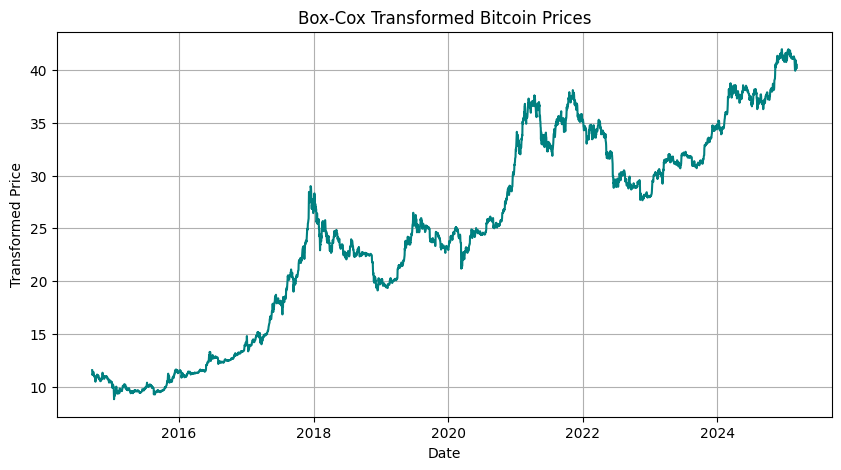

In [ ]:
from scipy.stats import boxcox

# It must be > 0 for Box-Cox
close_data = df['Close'].dropna()

# Apply the transformation
transformed_data, lambda_val = boxcox(close_data)

print(f"Optimal lambda: {lambda_val}")

# You can now plot it
plt.figure(figsize=(10, 5))
plt.plot(df.index[-len(transformed_data):], transformed_data, color='teal')
plt.title('Box-Cox Transformed Bitcoin Prices')
plt.xlabel('Date')
plt.ylabel('Transformed Price')
plt.grid(True)
plt.show()

If the optimal lamba value in the box-cox is 0 then it converts to log transformation

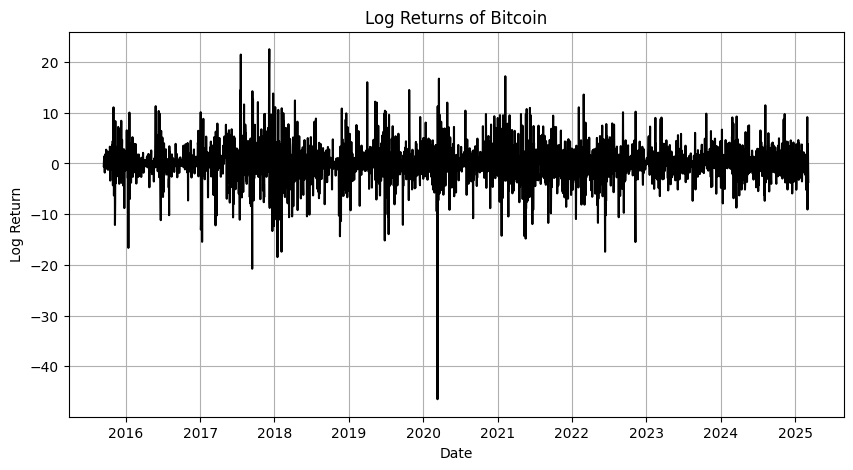

In [ ]:
df['Log_Returns'] = 100 * np.log(df['Close'] / df['Close'].shift(1))

# Drop the first row with NaN
df = df.dropna()

# Plot log returns
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Log_Returns'], color='black')
plt.title('Log Returns of Bitcoin')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.grid(True)
plt.show()


<ipython-input-10-3fa20761cdf0>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['outlier'] = (df['Log_Returns'] < lower_bound) | (df['Log_Returns'] > upper_bound)


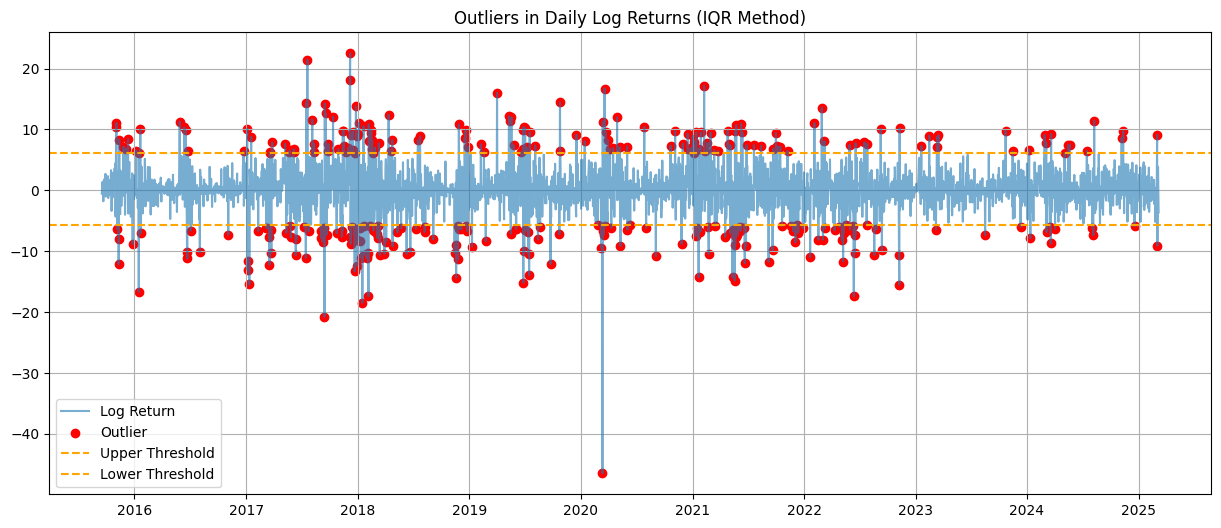

In [ ]:
# Calculate IQR
Q1 = df['Log_Returns'].quantile(0.25)
Q3 = df['Log_Returns'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find anomalies
df['outlier'] = (df['Log_Returns'] < lower_bound) | (df['Log_Returns'] > upper_bound)

# Plot
plt.figure(figsize=(15,6))
plt.plot(df['Log_Returns'], label='Log Return', alpha=0.6)
plt.scatter(df[df['outlier']].index, df[df['outlier']]['Log_Returns'], color='red', label='Outlier')
plt.axhline(upper_bound, color='orange', linestyle='--', label='Upper Threshold')
plt.axhline(lower_bound, color='orange', linestyle='--', label='Lower Threshold')
plt.title('Outliers in Daily Log Returns (IQR Method)')
plt.legend()
plt.grid(True)
plt.show()


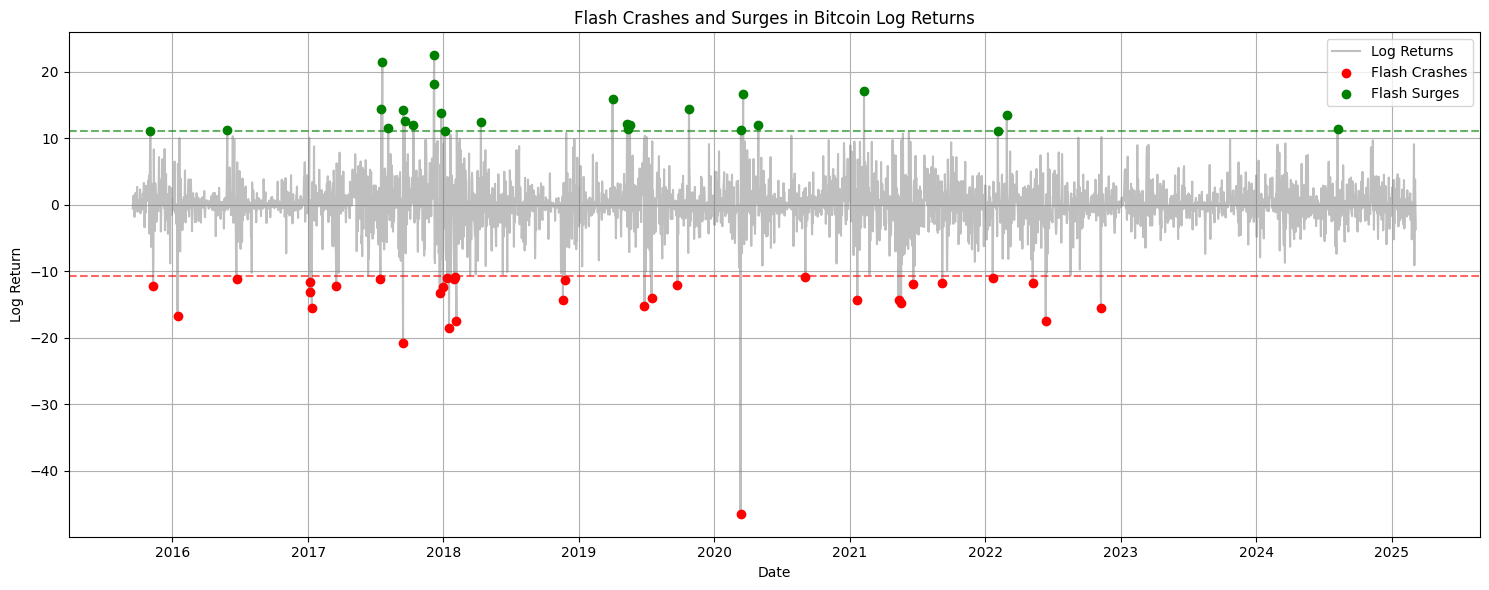

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Compute thresholds
mean = df['Log_Returns'].mean()
std = df['Log_Returns'].std()

crash_thresh = mean - 3 * std
surge_thresh = mean + 3 * std

# Step 2: Detect flash crashes and surges
flash_crashes = df[df['Log_Returns'] < crash_thresh]
flash_surges = df[df['Log_Returns'] > surge_thresh]

# Step 3: Plot
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Log_Returns'], label='Log Returns', color='gray', alpha=0.5)
plt.scatter(flash_crashes.index, flash_crashes['Log_Returns'], color='red', label='Flash Crashes', zorder=5)
plt.scatter(flash_surges.index, flash_surges['Log_Returns'], color='green', label='Flash Surges', zorder=5)
plt.axhline(crash_thresh, color='red', linestyle='--', alpha=0.6)
plt.axhline(surge_thresh, color='green', linestyle='--', alpha=0.6)
plt.title('Flash Crashes and Surges in Bitcoin Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

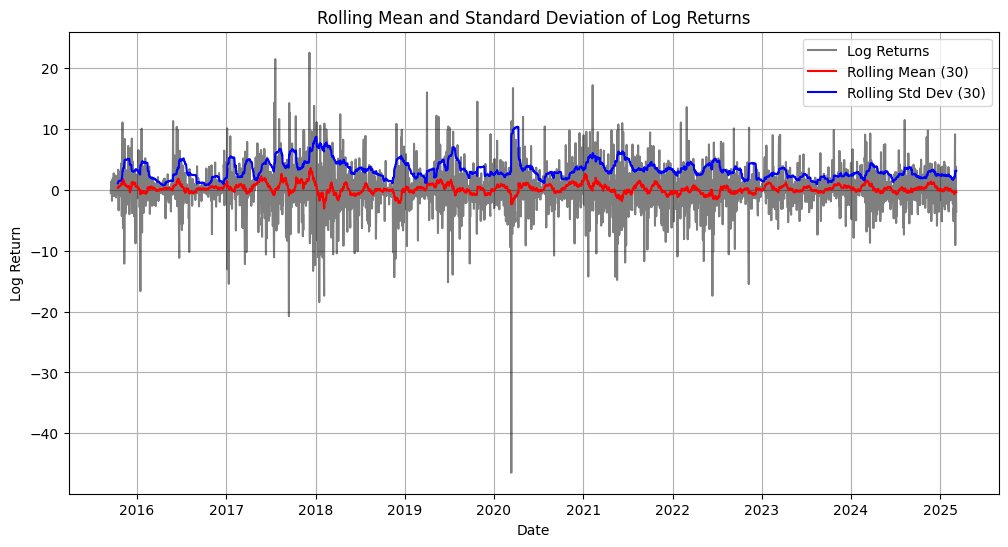

In [ ]:
# Rolling window size (e.g., 30 days, adjust as needed)
window = 30

# Rolling mean and standard deviation
rolling_mean = df['Log_Returns'].rolling(window=window).mean()
rolling_std = df['Log_Returns'].rolling(window=window).std()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df['Log_Returns'], label='Log Returns', color='black', alpha=0.5)
plt.plot(rolling_mean, label=f'Rolling Mean ({window})', color='red')
plt.plot(rolling_std, label=f'Rolling Std Dev ({window})', color='blue')
plt.title('Rolling Mean and Standard Deviation of Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend(loc='best')
plt.grid(True)
plt.show()

#3. Stationarity Check

In [ ]:
#ADF Test
adf_result = adfuller(df['Close'])

# Print results
print('ADF Statistic: %f' % adf_result[0])
print('p-value: %f' % adf_result[1])
print('Critical Values:')
for key, value in adf_result[4].items():
    print('\t%s: %.3f' % (key, value))

# Interpretation
if adf_result[1] <= 0.05:
    print("The series is likely stationary.")
else:
    print("The series is likely not stationary.")

ADF Statistic: -0.565120
p-value: 0.878670
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567
The series is likely not stationary.


# 4. Transformation & Difference

In [ ]:
df['log_Close'] = np.log(df['Close'])

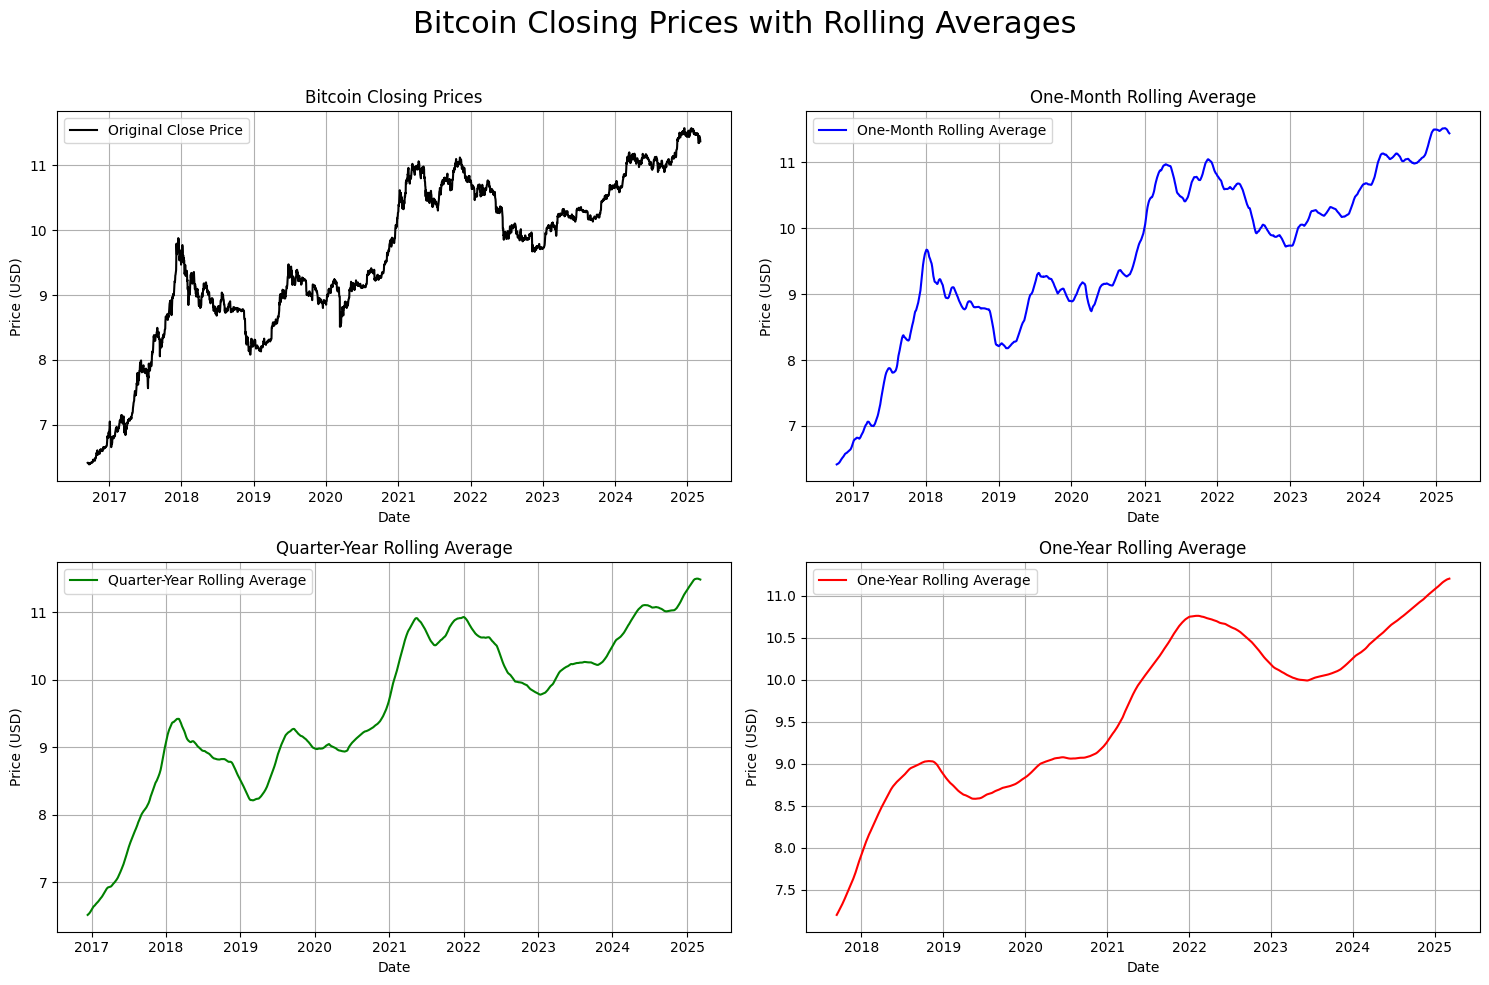

In [ ]:
#rolling mean for weeks and months and year
df['log_rolling_year'] = df['log_Close'].rolling(window=365).mean()
df['log_rolling_quarter'] = df['log_Close'].rolling(window=90).mean()
df['log_rolling_month'] = df['log_Close'].rolling(window=30).mean()

# Create a figure with a 2x2 subplot layout
fig = plt.figure(figsize=[15, 10])
plt.suptitle('Bitcoin Closing Prices with Rolling Averages', fontsize=22)

# Subplot 1: Original Close Price
plt.subplot(221)
plt.plot(df.index, df['log_Close'], label='Original Close Price', color='black')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.title('Bitcoin Closing Prices')

# Subplot 2: One-Month Rolling Average
plt.subplot(222)
plt.plot(df.index, df['log_rolling_month'], label='One-Month Rolling Average', color='blue')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.title('One-Month Rolling Average')

# Subplot 3: Quarter-Year Rolling Average
plt.subplot(223)
plt.plot(df.index, df['log_rolling_quarter'], label='Quarter-Year Rolling Average', color='green')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.title('Quarter-Year Rolling Average')

# Subplot 4: One-Year Rolling Average
plt.subplot(224)
plt.plot(df.index, df['log_rolling_year'], label='One-Year Rolling Average', color='red')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.title('One-Year Rolling Average')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust spacing to fit suptitle
plt.show()

This helps us better observe any possible trends. From these plots we can see the possibility of a linear trend present in our transformed data.

<ipython-input-15-f877fb331be9>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_Close_diff'] = df['log_Close'].diff()
<ipython-input-15-f877fb331be9>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_Close_diff_m'] = df['log_rolling_month'].diff()


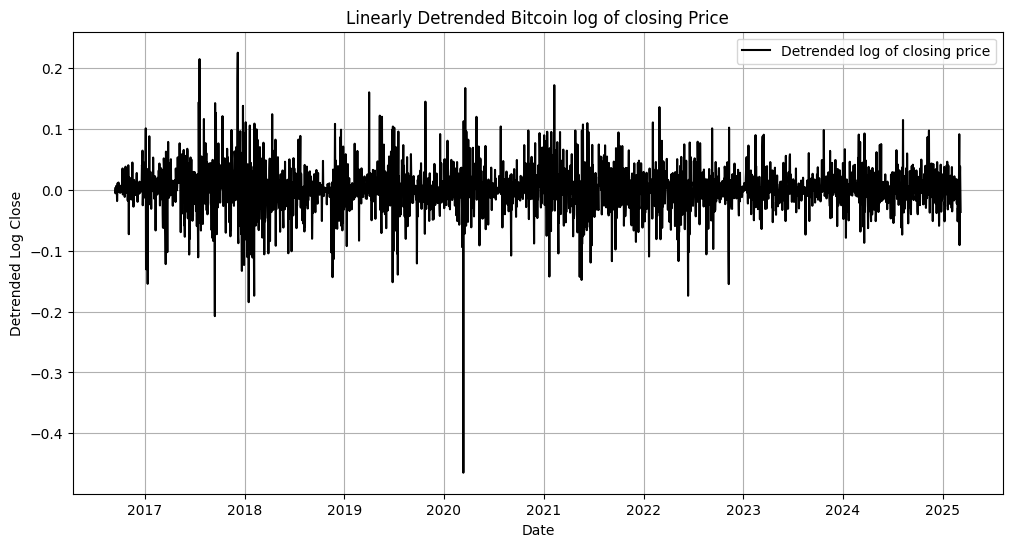

In [ ]:
# Linear Detrending using differencing
df['log_Close_diff'] = df['log_Close'].diff()
df['log_Close_diff_m'] = df['log_rolling_month'].diff()

# Remove the first row (NaN due to differencing)
df = df.dropna()

# Plot the detrended data
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['log_Close_diff'], label='Detrended log of closing price', color='black')
plt.xlabel('Date')
plt.ylabel('Detrended Log Close')
plt.title('Linearly Detrended Bitcoin log of closing Price')
plt.legend()
plt.grid(True)
plt.show()

# 5. Analysis of Detrended Series

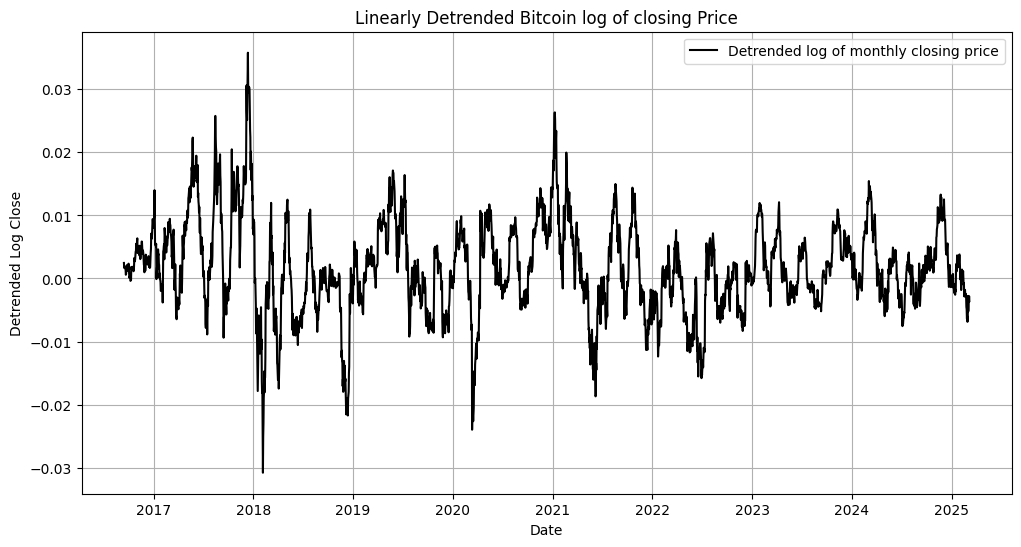

In [ ]:
# Plot the detrended data
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['log_Close_diff_m'], label='Detrended log of monthly closing price', color='black')
plt.xlabel('Date')
plt.ylabel('Detrended Log Close')
plt.title('Linearly Detrended Bitcoin log of closing Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Perform ADF test
adf_result = adfuller(df['log_Close_diff'])

# Print results
print('ADF Statistic: %.6f' % adf_result[0])
print('p-value: %.6f' % adf_result[1])
print('Critical Values:')
for key, value in adf_result[4].items():
    print('\t%s: %.6f' % (key, value))

# Interpretation
if adf_result[1] <= 0.05:
    print("The series is likely stationary.")
else:
    print("The series is likely not stationary.")

ADF Statistic: -38.509162
p-value: 0.000000
Critical Values:
	1%: -3.432465
	5%: -2.862474
	10%: -2.567267
The series is likely stationary.


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

# Assuming your detrended log returns are in a pandas Series
detrended = df['log_Close_diff']

mean = np.mean(detrended)
variance = np.var(detrended)
skewness = skew(detrended)
kurt = kurtosis(detrended)  # default is Fisher's definition (normal = 0)

print(f"Mean: {mean:.6f}")
print(f"Variance: {variance:.6f}")
print(f"Skewness: {skewness:.6f}")
print(f"Kurtosis: {kurt:.6f}")


Mean: 0.001601
Variance: 0.001366
Skewness: -0.671608
Kurtosis: 11.666637


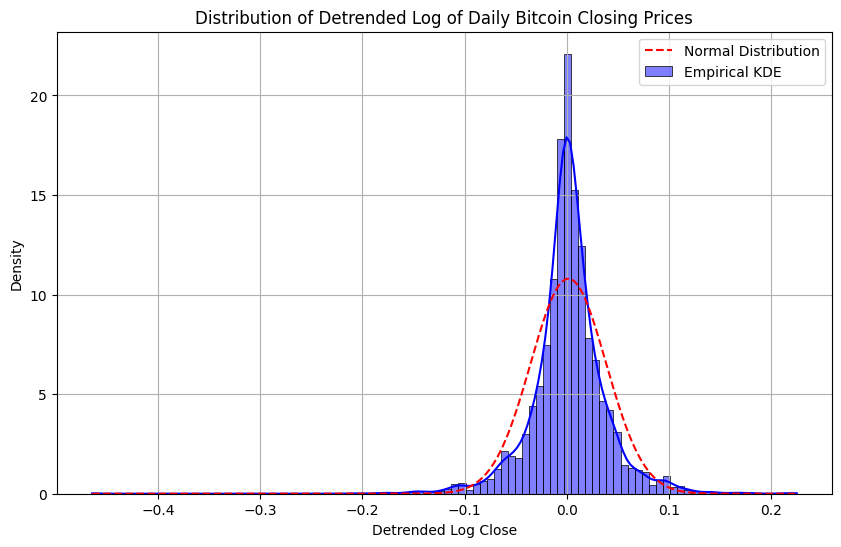

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

data = df['log_Close_diff'].dropna()

# Plot
plt.figure(figsize=(10,6))
sns.histplot(data, bins=100, kde=True, stat='density', color='blue', label='Empirical KDE')

# Overlay a normal distribution with same mean and std
mean = np.mean(data)
std = np.std(data)
x = np.linspace(min(data), max(data), 1000)
plt.plot(x, stats.norm.pdf(x, mean, std), 'r--', label='Normal Distribution')

# Titles and legend
plt.title('Distribution of Detrended Log of Daily Bitcoin Closing Prices')
plt.xlabel('Detrended Log Close')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

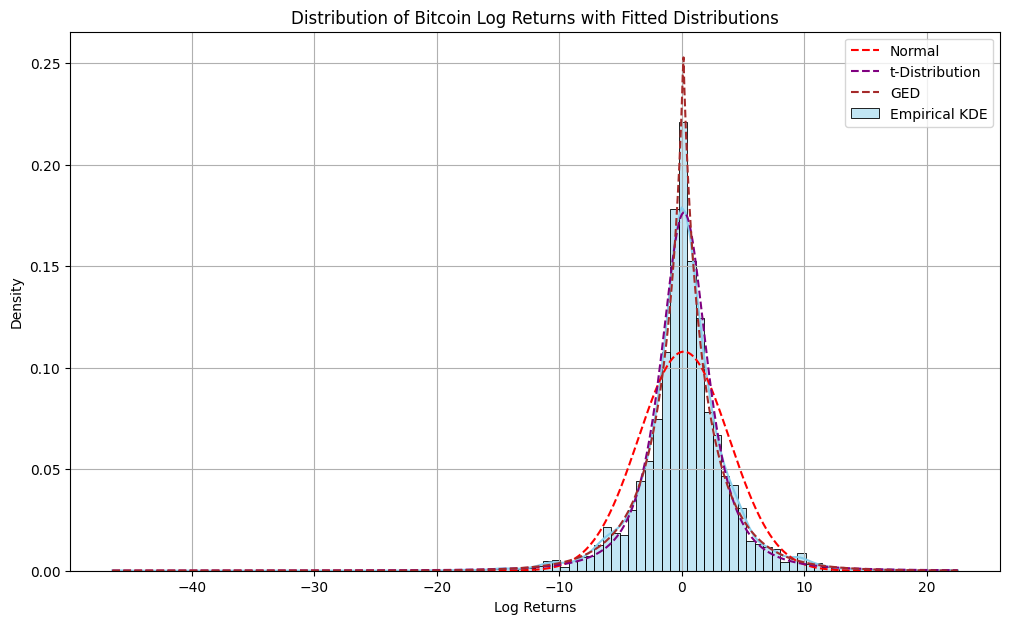

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

# Assuming df['Log_Returns'] is already computed and cleaned
data = df['Log_Returns'].dropna()

# Setup plot
plt.figure(figsize=(12, 7))
sns.histplot(data, bins=100, stat='density', kde=True, color='skyblue', label='Empirical KDE')

# Create x-values for fitting curves
x = np.linspace(data.min(), data.max(), 1000)

# Fit and plot Normal distribution
mean, std = stats.norm.fit(data)
plt.plot(x, stats.norm.pdf(x, mean, std), 'r--', label='Normal')

# Fit and plot Laplace distribution
loc_lap, scale_lap = stats.laplace.fit(data)
#plt.plot(x, stats.laplace.pdf(x, loc_lap, scale_lap), 'g--', label='Laplace')

# Fit and plot t-distribution
df_t, loc_t, scale_t = stats.t.fit(data)
plt.plot(x, stats.t.pdf(x, df_t, loc_t, scale_t), 'purple', linestyle='--', label='t-Distribution')

# Fit and plot Logistic distribution
loc_log, scale_log = stats.logistic.fit(data)
#plt.plot(x, stats.logistic.pdf(x, loc_log, scale_log), 'orange', linestyle='--', label='Logistic')

# Optional: Generalized Error Distribution (GED)
try:
    from scipy.stats import gennorm
    beta, loc_ged, scale_ged = gennorm.fit(data)
    plt.plot(x, gennorm.pdf(x, beta, loc_ged, scale_ged), 'brown', linestyle='--', label='GED')
except ImportError:
    pass  # if gennorm not available

# Finalize plot
plt.title('Distribution of Bitcoin Log Returns with Fitted Distributions')
plt.xlabel('Log Returns')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


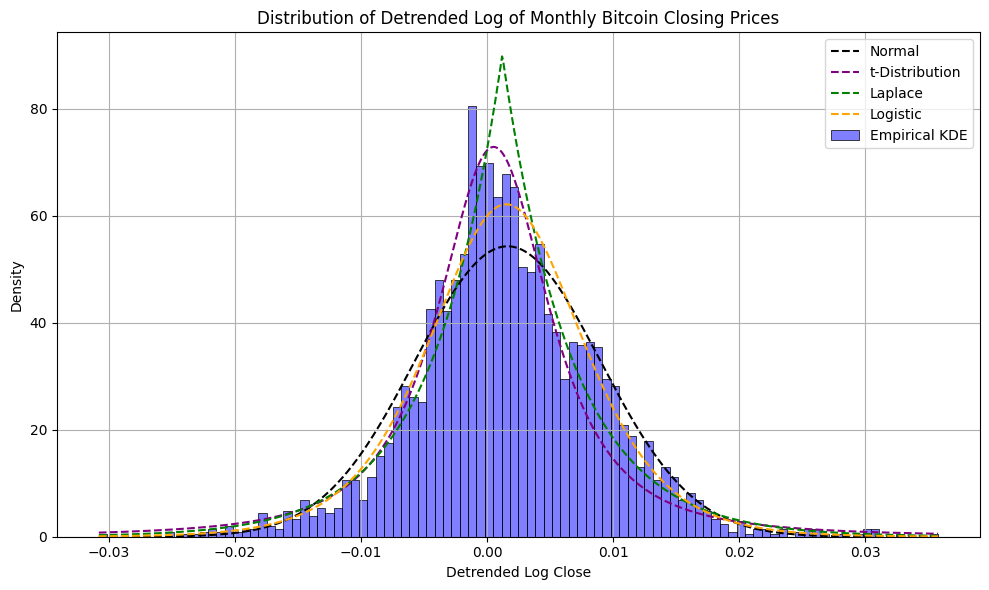

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

data = df['log_Close_diff_m'].dropna()

plt.figure(figsize=(10,6))
sns.histplot(data, bins=100, kde=False, stat='density', color='blue', label='Empirical KDE', alpha=0.5)

x = np.linspace(min(data), max(data), 1000)

# Empirical mean and std
mean, std = np.mean(data), np.std(data)

# 1. Normal distribution
plt.plot(x, stats.norm.pdf(x, mean, std), 'black', linestyle='--', label='Normal')

# 2. Student's t-distribution
df_t, loc_t, scale_t = stats.t.fit(data)
plt.plot(x, stats.t.pdf(x, df_t, loc_t, scale_t), 'purple', linestyle='--', label='t-Distribution')


# 4. Laplace distribution
loc_lap, scale_lap = stats.laplace.fit(data)
plt.plot(x, stats.laplace.pdf(x, loc_lap, scale_lap), 'green', linestyle='--', label='Laplace')

# 5. Logistic distribution
loc_log, scale_log = stats.logistic.fit(data)
plt.plot(x, stats.logistic.pdf(x, loc_log, scale_log), 'orange', linestyle='--', label='Logistic')


# Final touches
plt.title('Distribution of Detrended Log of Monthly Bitcoin Closing Prices')
plt.xlabel('Detrended Log Close')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


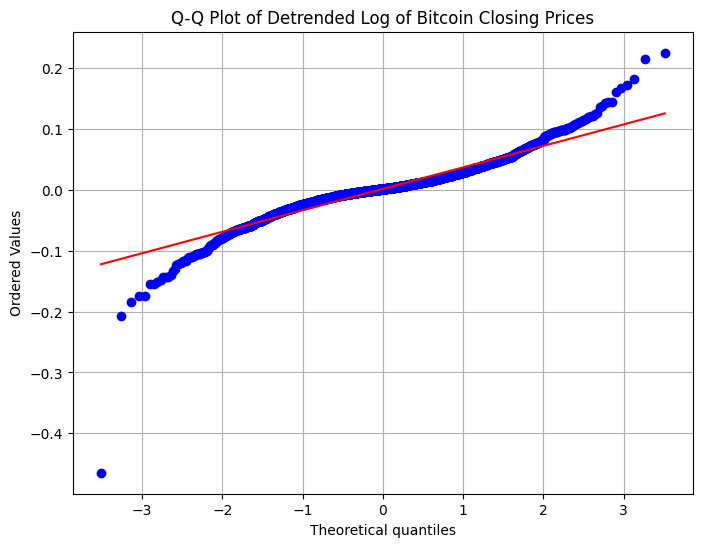

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Assuming your Series is called 'detrended_log_close'
data = df['log_Close_diff'].dropna()

# Q-Q plot
plt.figure(figsize=(8, 6))
stats.probplot(data, dist="norm", plot=plt)
plt.title('Q-Q Plot of Detrended Log of Bitcoin Closing Prices')
plt.grid(True)
plt.show()

In [ ]:
monthly_data = df['log_Close_diff_m'].dropna()

<Figure size 1000x500 with 0 Axes>

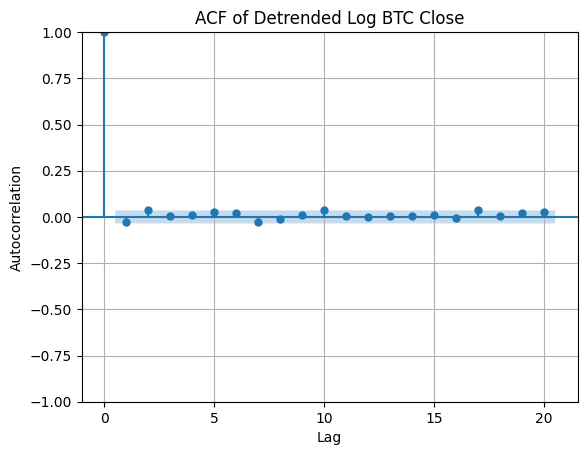

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 5))
plot_acf(data, lags=20)  # You can increase or decrease lags
plt.title("ACF of Detrended Log BTC Close")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()

<Figure size 1000x500 with 0 Axes>

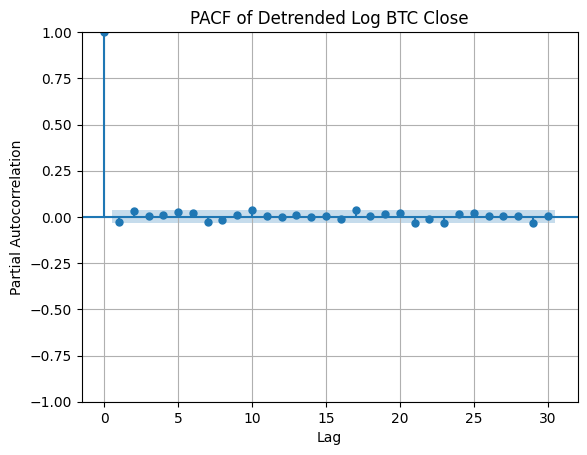

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10, 5))
plot_pacf(data, lags=30, method='ywm')  # 'ywm' is a stable method
plt.title("PACF of Detrended Log BTC Close")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.grid(True)
plt.show()

In [ ]:
returns = df['Log_Returns']

# 6. Correlation of Closing Price with Volume

count    3.097000e+03
mean     2.361394e+10
std      2.073371e+10
min      3.397780e+07
25%      6.925190e+09
50%      2.044390e+10
75%      3.345136e+10
max      3.509679e+11
Name: Volume, dtype: float64
Skewness: 2.4924724419392783
Kurtosis: 22.37765672921567


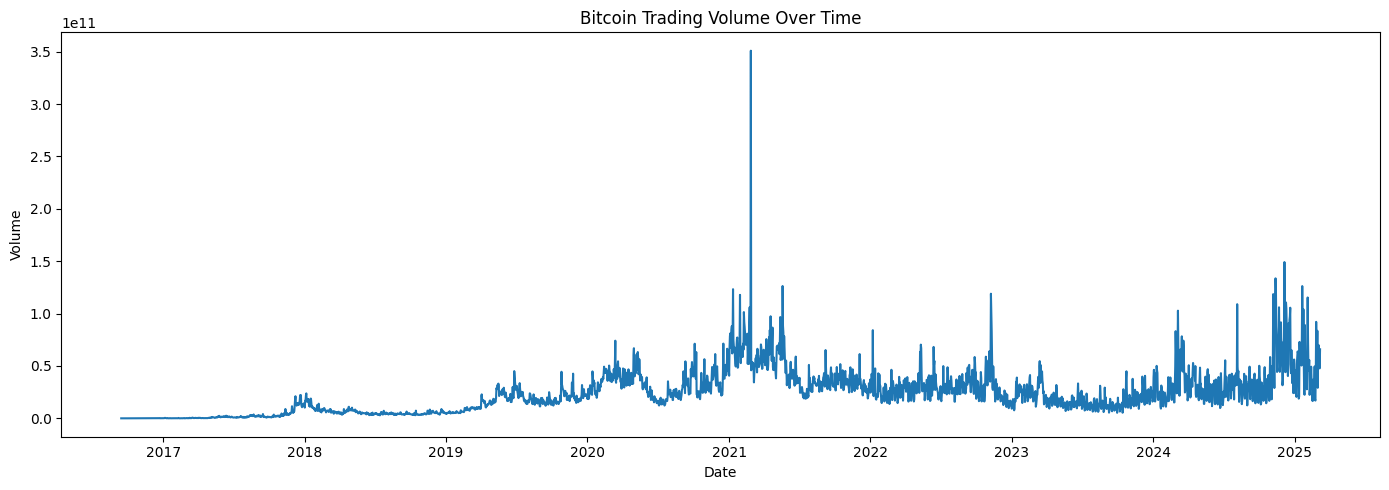

<function matplotlib.pyplot.figure(num: 'int | str | Figure | SubFigure | None' = None, figsize: 'tuple[float, float] | None' = None, dpi: 'float | None' = None, *, facecolor: 'ColorType | None' = None, edgecolor: 'ColorType | None' = None, frameon: 'bool' = True, FigureClass: 'type[Figure]' = <class 'matplotlib.figure.Figure'>, clear: 'bool' = False, **kwargs) -> 'Figure'>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Summary statistics
volume_stats = df['Volume'].describe()
print(volume_stats)
print("Skewness:", df['Volume'].skew())
print("Kurtosis:", df['Volume'].kurt())

# 2. Line plot of volume
plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x=df.index, y='Volume')
plt.title("Bitcoin Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()

# 3. Rolling statistics
df['Volume_rolling_mean'] = df['Volume'].rolling(window=30).mean()
df['Volume_rolling_std'] = df['Volume'].rolling(window=30).std()

# Plot rolling mean and std
plt.figure


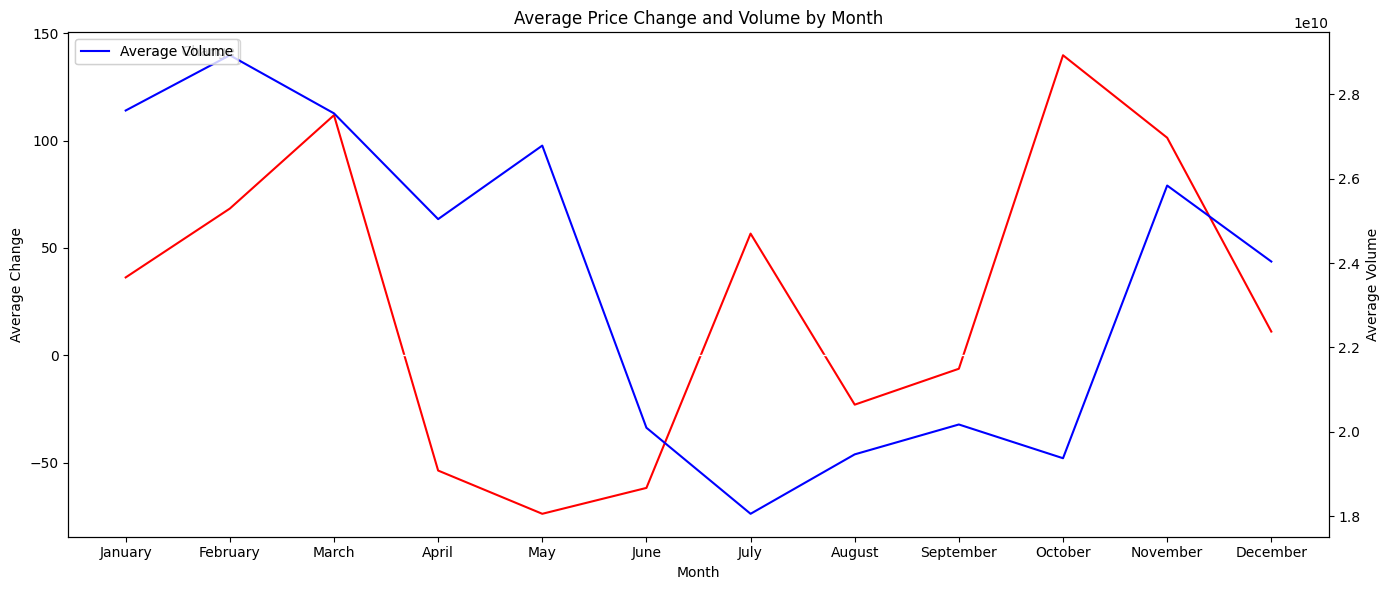

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract month name and number
df['Month'] = df.index.month_name()
df['Month_Num'] = df.index.month

# 2. Calculate price change (daily difference)
df['Price_Change'] = df['Close'].diff()

# 3. Group by month and calculate mean price change and volume
monthly = df.groupby(['Month_Num', 'Month']).agg({
    'Price_Change': 'mean',
    'Volume': 'mean'
}).sort_index()

# 4. Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Left y-axis: Average Price Change
#legend

color1 = 'red'
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Change', color='black')
ax1.plot(monthly.index.get_level_values(1), monthly['Price_Change'], color=color1, label='Average Change')
ax1.tick_params(axis='y', labelcolor='black')
ax1.axhline(0, color='white', linewidth=1)
plt.legend(loc='upper left')

# Right y-axis: Average Volume
ax2 = ax1.twinx()
color2 = 'blue'
ax2.set_ylabel('Average Volume', color='black')
ax2.plot(monthly.index.get_level_values(1), monthly['Volume'], color=color2, label='Average Volume')
ax2.tick_params(axis='y', labelcolor='black')

# Title and layout
#legend
plt.legend(loc='upper left')
plt.title("Average Price Change and Volume by Month")
fig.tight_layout()

plt.show()

Correlation between Close and Volume: 0.5991276575036122


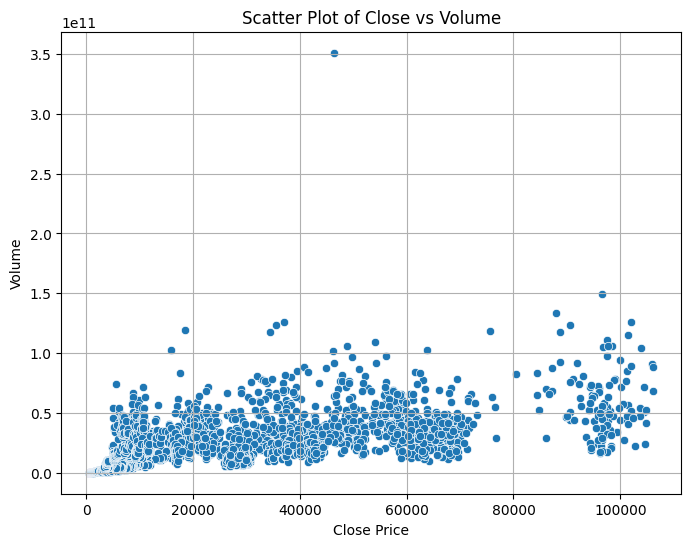

In [ ]:
correlation = df['Close'].corr(df['Volume'])

print("Correlation between Close and Volume:", correlation)

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Close', y='Volume', data=df)
plt.title('Scatter Plot of Close vs Volume')
plt.xlabel('Close Price')
plt.ylabel('Volume')
plt.grid(True)
plt.show()


corr_matrix = df[['Close', 'Volume']].corr()


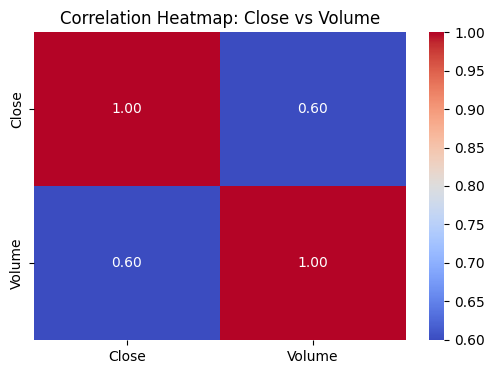

In [ ]:
# Calculate the correlation matrix
corr_matrix = df[['Close', 'Volume']].corr()

# Create the heatmap
plt.figure(figsize=(6, 4))  # Adjust figure size if needed
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Close vs Volume')
plt.show()